# Review of Statistics and Probability III
**HS 821 · Lecture 3 · Topics in Time Series Econometrics**

**Sunil Paul**

12 August 2026 · R 4.6

This is the third and final part of the review. Parts I–II introduced probability, random variables, sampling, and estimators. Here we turn to **statistical inference**: how we use a sample to learn about unknown population parameters.

The emphasis is on the intuition behind **likelihood**, **frequentist inference**, and **Bayesian inference**. We first study one unknown probability using a loan-default example, and then apply the same logic to a linear regression.


## Statistical inference: what are we trying to do?

Suppose a probability model contains an unknown parameter $\theta$.

We observe a sample

$$
y=(y_1,\ldots,y_n)
$$

and want to learn about $\theta$.

**Estimation** gives us plausible values for the unknown parameter.  
**Inference** tells us how uncertain we should be about those values.

Two major approaches are used:

| Framework | Main idea |
|:---|:---|
| **Frequentist** | Treat the parameter as fixed but unknown and study how an estimator behaves across repeated samples |
| **Bayesian** | Represent uncertainty about the parameter with a probability distribution and update it using the observed data |

For likelihood-based methods, both approaches begin with the same ingredient: a **probability model for the data**.


## From a probability model to a likelihood

### Example: estimating a loan-default probability

Suppose a bank observes **50 comparable loans**, of which **8 default**.

Let

$$
D_i=
\begin{cases}
1, & \text{if loan }i\text{ defaults},\\
0, & \text{otherwise}.
\end{cases}
$$

Assume each loan has the same unknown probability of default $p$:

$$
D_i\overset{iid}{\sim}\operatorname{Bernoulli}(p).
$$

The unknown parameter is therefore

$$
p\in(0,1).
$$

If $k$ defaults are observed among $n$ independent loans, then

$$
K=\sum_{i=1}^{n}D_i\sim\operatorname{Binomial}(n,p).
$$

For our data,

$$
n=50,\qquad k=8.
$$


### Constructing the likelihood

For any proposed value of $p$, the probability of observing exactly $k=8$ defaults is

$$
P(K=8\mid p)
=
{50\choose 8}p^8(1-p)^{42}.
$$

Once the data have been observed, $k=8$ is fixed. We now regard this expression as a function of the unknown parameter $p$:

$$
L(p;k)
=
{50\choose 8}p^8(1-p)^{42}.
$$

Terms that do not depend on $p$ do not affect which value maximises the likelihood, so we often write

$$
L(p)\propto p^8(1-p)^{42}.
$$

**Intuition:** different values of $p$ make the observed result—8 defaults in 50 loans—more or less compatible with the probability model. The likelihood measures this **relative support**.

More generally,

$$
L(\theta;y)=f(y\mid\theta).
$$

The observed data $y$ are held fixed and the likelihood is viewed as a function of $\theta$.

> **Important:** a likelihood is not itself a probability distribution for the parameter. It does not need to integrate to one over $\theta$.


[1] 0.16

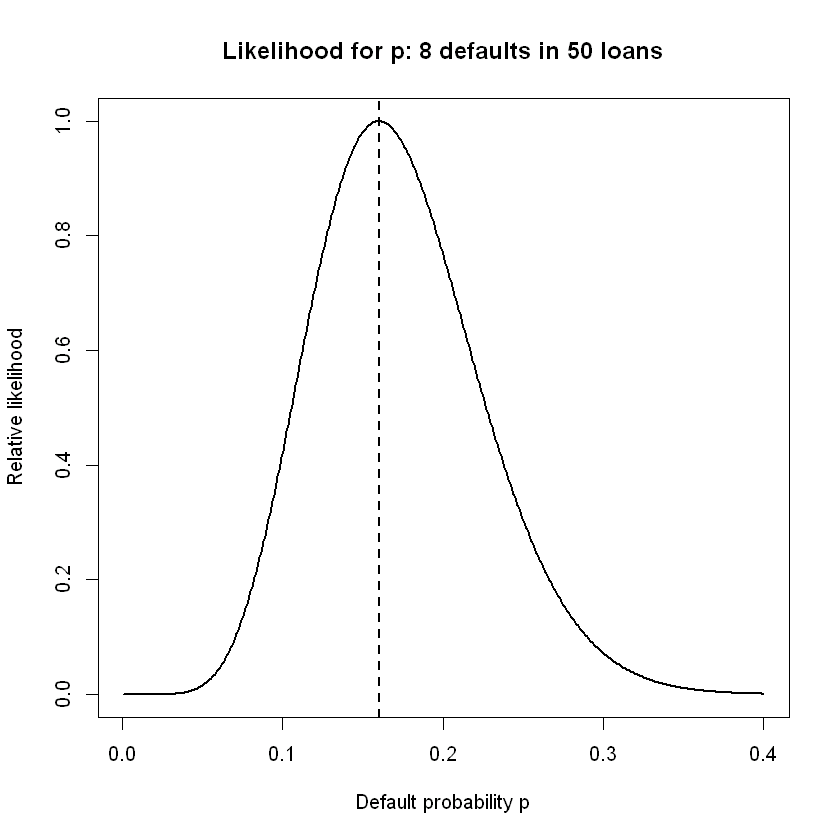

In [1]:
# Likelihood for the loan-default probability

n <- 50
k <- 8

p_grid <- seq(0.001, 0.40, length.out = 500)

log_lik <- dbinom(
  k,
  size = n,
  prob = p_grid,
  log = TRUE
)

# Scale the likelihood so its maximum is 1
rel_lik <- exp(log_lik - max(log_lik))

p_hat <- k / n

plot(
  p_grid, rel_lik,
  type = "l",
  lwd = 2,
  xlab = "Default probability p",
  ylab = "Relative likelihood",
  main = "Likelihood for p: 8 defaults in 50 loans"
)

abline(v = p_hat, lty = 2, lwd = 2)

p_hat


The likelihood peaks at

$$
\hat p=\frac{8}{50}=0.16.
$$

This is the **maximum-likelihood estimate (MLE)**.

The data therefore provide greatest support to a default probability of about 16%, although nearby values are also plausible. Inference asks how much uncertainty remains around this estimate.


## Frequentist inference: uncertainty through repeated sampling

In the frequentist framework, $p$ is a **fixed but unknown constant**.

Before the sample is observed, the data are random. Therefore the estimator

$$
\hat p=\frac{K}{n}
$$

is also random.

The logic is

$$
\text{probability model}
\longrightarrow
\text{estimator}
\longrightarrow
\text{sampling distribution}
\longrightarrow
\text{SE, confidence interval, test}.
$$

### Standard error

The **standard error** is the standard deviation of an estimator's sampling distribution. It measures how much the estimate would vary from sample to sample.

### Confidence interval

A 95% confidence-interval **procedure** is constructed so that, under repeated sampling, about 95% of the intervals produced by that procedure contain the true parameter.

The 95% refers to the **procedure**, not to a probability assigned to the fixed parameter after this particular interval has been calculated.

### Hypothesis test and p-value

A hypothesis test asks whether the observed result would be unusual if a specified null hypothesis were true.

For example,

$$
H_0:p=0.10.
$$

The **p-value** is the probability, under the null model, of obtaining a test statistic at least as extreme as the one observed. It is **not** the probability that $H_0$ is true.


In [2]:
# Frequentist inference for p

p_hat <- k / n

# Exact (Clopper-Pearson) test and interval
default_test <- binom.test(
  x = k,
  n = n,
  p = 0.10,
  conf.level = 0.95
)

# Normal-approximation (Wald) standard error and interval, for comparison
wald_se <- sqrt(p_hat * (1 - p_hat) / n)
wald_ci <- p_hat + c(-1, 1) * 1.96 * wald_se

cat("p_hat      =", round(p_hat, 4), "\n")
cat("Wald SE    =", round(wald_se, 4), "\n")
cat("Wald 95% CI=", round(wald_ci, 4), "\n\n")

default_test

p_hat      = 0.16 
Wald SE    = 0.0518 
Wald 95% CI= 0.0584 0.2616 




	Exact binomial test

data:  k and n
number of successes = 8, number of trials = 50, p-value = 0.1559
alternative hypothesis: true probability of success is not equal to 0.1
95 percent confidence interval:
 0.07170077 0.29112631
sample estimates:
probability of success 
                  0.16 


**Reading the result**

- The point estimate is $\hat p=0.16$.
- `binom.test` reports the **exact (Clopper–Pearson) interval**, $[0.072,\,0.291]$. It is not symmetric around $\hat p$ and differs slightly from the Wald interval $\hat p \pm 1.96\,\widehat{\mathrm{SE}}$ printed above; the two agree more closely as $n$ grows.
- The p-value ($\approx 0.16$) evaluates how unusual 8 defaults in 50 would be if the true default probability were 10%. At the 5% level it does **not** reject $H_0:p=0.10$.

The frequentist question is therefore:

> *How would our estimator behave if we repeatedly sampled loans from the same population?*

## Bayesian inference: updating uncertainty with data

Bayesian inference starts from the same likelihood but adds a **prior distribution** for the unknown parameter.

Bayes' rule gives

$$
\pi(p\mid y)
=
\frac{L(p;y)\pi(p)}
{\int L(p;y)\pi(p)\,dp},
$$

or, more compactly,

$$
\boxed{
\text{Posterior}
\propto
\text{Likelihood}
\times
\text{Prior}
}
$$

where:

- **Prior** $\pi(p)$ describes uncertainty about $p$ before seeing the current data.
- **Likelihood** $L(p;y)$ describes what the observed data say about different values of $p$.
- **Posterior** $\pi(p\mid y)$ describes uncertainty about $p$ after combining prior information with the data.

### A simple prior

Suppose previous experience suggests default rates around 10%. For illustration, take

$$
p\sim\operatorname{Beta}(2,18).
$$

Its prior mean is

$$
E(p)=\frac{2}{2+18}=0.10.
$$

The Beta distribution is convenient for probabilities because all of its mass lies between 0 and 1.


### Updating the prior

For a Binomial likelihood and a Beta prior,

$$
p\sim\operatorname{Beta}(a,b),
$$

the posterior is again Beta:

$$
p\mid y
\sim
\operatorname{Beta}(a+k,\;b+n-k).
$$

With $a=2$, $b=18$, $k=8$, and $n=50$,

$$
p\mid y
\sim
\operatorname{Beta}(10,60).
$$

The posterior mean is

$$
E(p\mid y)
=
\frac{10}{70}
\approx0.143.
$$

**Intuition:** the sample alone suggests 16%; the prior was centred at 10%; the posterior combines both sources of information and lies between them.


posterior_mean           lower_95           upper_95 P(p > 0.10 | data) 
            0.1429             0.0717             0.2332             0.8516

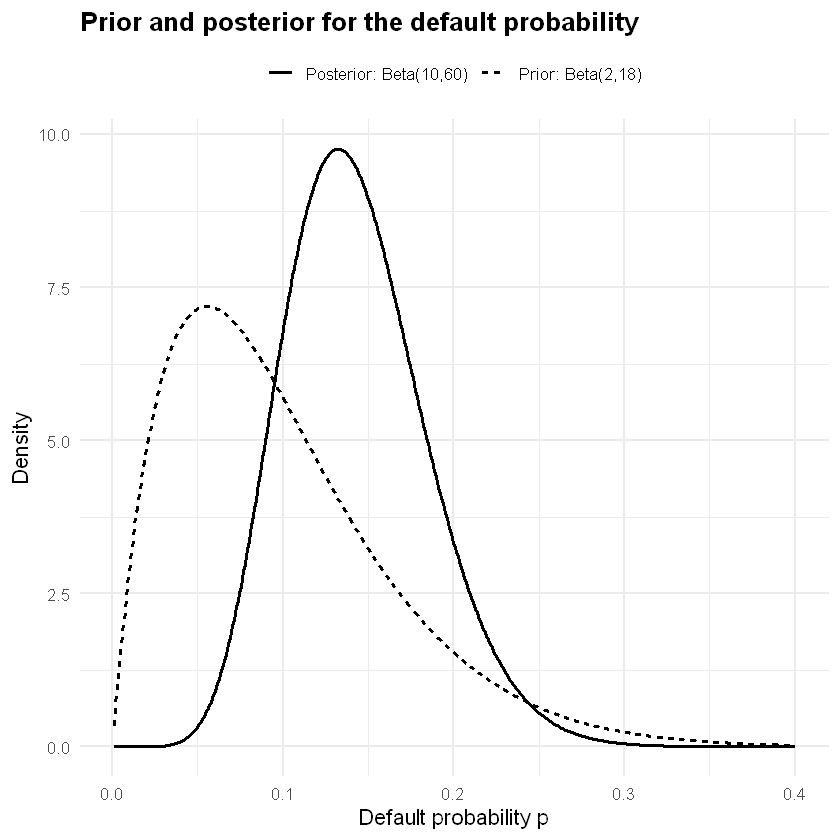

In [8]:
# Bayesian inference for p

a_prior <- 2
b_prior <- 18

a_post <- a_prior + k
b_post <- b_prior + n - k

posterior_mean <- a_post / (a_post + b_post)
credible_interval <- qbeta(c(0.025, 0.975), a_post, b_post)
prob_above_10 <- 1 - pbeta(0.10, a_post, b_post)

round(
  c(
    posterior_mean = posterior_mean,
    lower_95 = credible_interval[1],
    upper_95 = credible_interval[2],
    `P(p > 0.10 | data)` = prob_above_10
  ),
  4
)

library(ggplot2)

# Grid of possible values of p
p_grid <- seq(0.001, 0.40, length.out = 500)

# Data for plotting
plot_data <- data.frame(
  p = rep(p_grid, 2),
  density = c(
    dbeta(p_grid, a_prior, b_prior),
    dbeta(p_grid, a_post, b_post)
  ),
  distribution = rep(
    c("Prior: Beta(2,18)", "Posterior: Beta(10,60)"),
    each = length(p_grid)
  )
)

ggplot(plot_data, aes(x = p, y = density,
                      linetype = distribution)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Prior and posterior for the default probability",
    x = "Default probability p",
    y = "Density",
    linetype = NULL
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "top",
    plot.title = element_text(face = "bold")
  )


A 95% **credible interval** contains 95% of the posterior probability for $p$, conditional on the model, prior, and observed data.

Unlike a frequentist confidence interval, we can also ask direct probability questions such as

$$
P(p>0.10\mid y).
$$

On these data that posterior probability is about **0.85**, while the exact frequentist test does **not** reject $H_0:p=0.10$ at the 5% level (p-value $\approx 0.16$). The two results are not in conflict: they answer different questions. The test asks how surprising 8 defaults in 50 would be *if* $p=0.10$; the posterior asks how probable $p>0.10$ is *given* the data and prior.

### Frequentist and Bayesian inference compared

| Question | Frequentist | Bayesian |
|:---|:---|:---|
| Unknown parameter | fixed but unknown | uncertainty represented by a distribution |
| Data model | Binomial likelihood | same Binomial likelihood |
| Additional ingredient | repeated-sampling principle | prior distribution |
| Point summary | MLE $\hat p$ | posterior mean/median/mode |
| Uncertainty | sampling distribution | posterior distribution |
| Interval | confidence interval | credible interval |
| Probability statement | about repeated samples/procedures | about the parameter conditional on model, prior and data |

The two approaches use the **same observed data and likelihood**, but represent and interpret uncertainty differently.


## From one parameter to regression

The loan example contains one unknown parameter, $p$. Econometric models usually contain several unknown parameters.

We now use an economic dataset and ask:

> **How is hourly wage associated with years of education?**

We use the `wage1` dataset from the **wooldridge** R package.

Let

$$
Y_i=\log(\text{hourly wage}_i),
\qquad
X_i=\text{years of education}_i.
$$

We consider the simple regression

$$
Y_i=\beta_0+\beta_1X_i+\varepsilon_i.
$$

This is an **associational** regression. By itself it does not establish that education has a causal effect on wages.


,wage,lwage,educ
,<dbl>,<dbl>,<int>
1,3.10,1.131402,11
2,3.24,1.175573,12
3,3.00,1.098612,11
4,6.00,1.791759,8
5,5.30,1.667707,12
6,8.75,2.169054,16


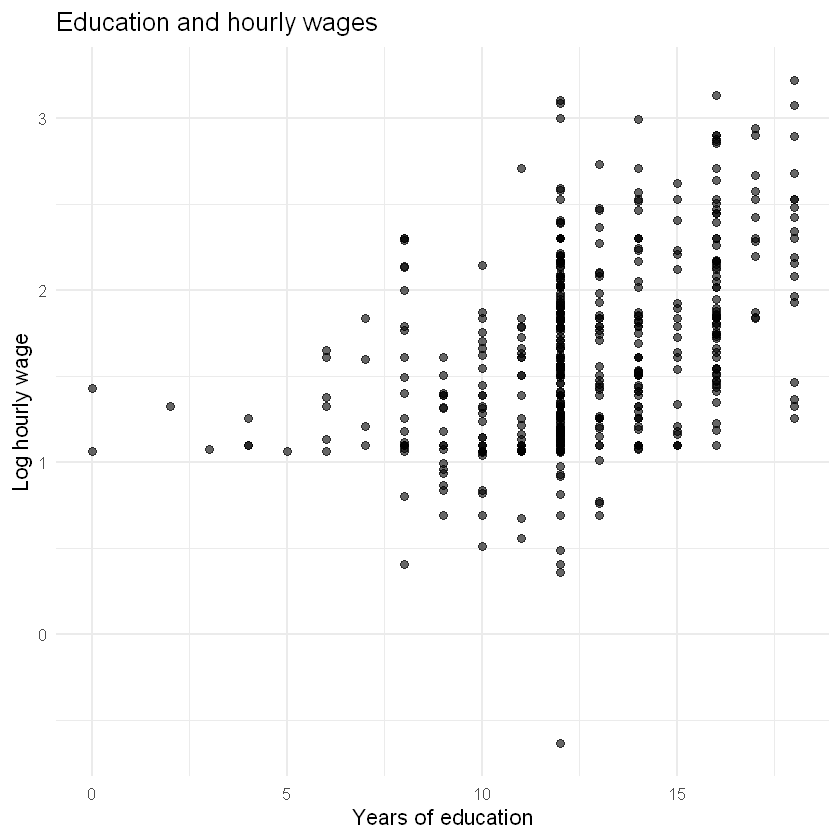

In [9]:
# Run once if the package is not installed:
 #install.packages("wooldridge")

if (!requireNamespace("wooldridge", quietly = TRUE)) {
  stop("Please install the 'wooldridge' package before running this cell.")
}

data("wage1", package = "wooldridge")

head(wage1[c("wage", "lwage", "educ")])

ggplot(wage1, aes(x = educ, y = lwage)) +
  geom_point(alpha = 0.6, size = 2) +
  labs(
    title = "Education and hourly wages",
    x = "Years of education",
    y = "Log hourly wage"
  ) +
  theme_minimal(base_size = 13)


## Creating the likelihood for a regression

The regression equation alone specifies the **conditional mean**:

$$
E(Y_i\mid X_i=x_i)
=
\beta_0+\beta_1x_i.
$$

To construct a likelihood, we also need a probability model for the disturbances. Assume

$$
\varepsilon_i\overset{iid}{\sim}N(0,\sigma^2).
$$

Then

$$
Y_i\mid X_i=x_i
\sim
N(\beta_0+\beta_1x_i,\sigma^2).
$$

The unknown parameter vector is

$$
\theta=(\beta_0,\beta_1,\sigma).
$$

For observation $i$,

$$
f(y_i\mid x_i,\theta)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left[
-\frac{(y_i-\beta_0-\beta_1x_i)^2}{2\sigma^2}
\right].
$$

Assuming conditional independence, the likelihood for the whole sample is

$$
L(\theta;y,X)
=
\prod_{i=1}^{n}
f(y_i\mid x_i,\theta).
$$

The log-likelihood is

$$
\ell(\theta)
=
-\frac{n}{2}\log(2\pi)
-n\log(\sigma)
-\frac{1}{2\sigma^2}
\sum_{i=1}^{n}
(y_i-\beta_0-\beta_1x_i)^2.
$$

### Why OLS appears

For a fixed $\sigma$, maximising the Gaussian log-likelihood with respect to $\beta_0$ and $\beta_1$ is equivalent to minimising

$$
\sum_{i=1}^{n}
(y_i-\beta_0-\beta_1x_i)^2.
$$

Therefore, under normally distributed errors, the maximum-likelihood estimates of the regression coefficients are the same as the **ordinary least-squares estimates**.


In [10]:
# Build and maximise the regression likelihood directly

y <- wage1$lwage
x <- wage1$educ

neg_loglik <- function(par, y, x) {

  beta0 <- par[1]
  beta1 <- par[2]

  # Parameterising log(sigma) guarantees sigma > 0
  sigma <- exp(par[3])

  mu <- beta0 + beta1 * x

  -sum(
    dnorm(
      y,
      mean = mu,
      sd = sigma,
      log = TRUE
    )
  )
}

mle_fit <- optim(
  par = c(0, 0, log(sd(y))),
  fn = neg_loglik,
  y = y,
  x = x,
  method = "BFGS",
  hessian = TRUE
)

mle_estimates <- c(
  beta0 = mle_fit$par[1],
  beta1 = mle_fit$par[2],
  sigma = exp(mle_fit$par[3])
)

round(mle_estimates, 4)


beta0  beta1  sigma 
0.5838 0.0827 0.4792

The computer searches over possible values of $(\beta_0,\beta_1,\sigma)$ and chooses the combination that makes the observed wage data most compatible with the Gaussian regression model.

Now compare the likelihood estimates with ordinary least squares.


In [11]:
# Ordinary least squares

fit <- lm(lwage ~ educ, data = wage1)

coef(fit)

# Compare OLS and maximum-likelihood coefficient estimates
rbind(
  MLE = mle_estimates[c("beta0", "beta1")],
  OLS = coef(fit)
)

# Standard errors also agree: MLE SEs from the inverted Hessian vs OLS SEs
mle_se <- sqrt(diag(solve(mle_fit$hessian)))[1:2]
se_tab <- rbind(
  `MLE SE` = unname(mle_se),
  `OLS SE` = unname(summary(fit)$coefficients[, "Std. Error"])
)
colnames(se_tab) <- c("beta0", "beta1")
round(se_tab, 4)

(Intercept)        educ 
 0.58377267  0.08274437

,beta0,beta1
MLE,0.5837725,0.08274438
OLS,0.5837727,0.08274437


,beta0,beta1
MLE SE,0.0972,0.0076
OLS SE,0.0973,0.0076


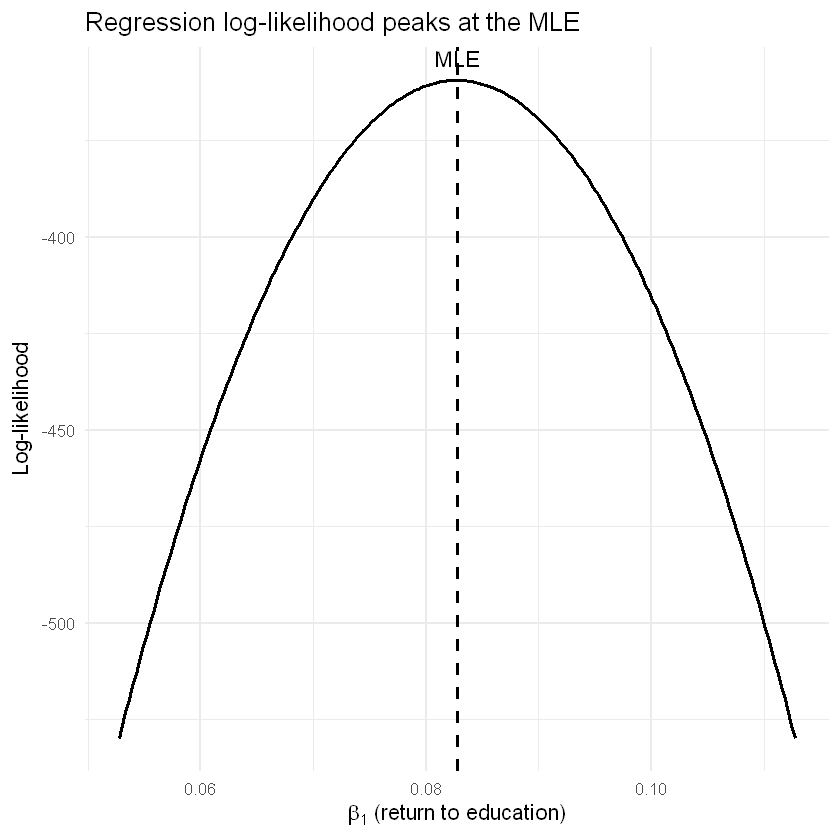

In [13]:
# The regression likelihood, viewed along the slope beta1
# (holding beta0 and sigma fixed at their MLE values)

b0_hat  <- mle_estimates["beta0"]
sig_hat <- mle_estimates["sigma"]

b1_grid <- seq(
  mle_estimates["beta1"] - 0.03,
  mle_estimates["beta1"] + 0.03,
  length.out = 200
)

profile_ll <- sapply(b1_grid, function(b1) {
  sum(dnorm(y, mean = b0_hat + b1 * x, sd = sig_hat, log = TRUE))
})

ll_data <- data.frame(
  beta1 = b1_grid,
  log_likelihood = profile_ll
)

ggplot(ll_data, aes(x = beta1, y = log_likelihood)) +
  geom_line(linewidth = 1) +
  geom_vline(
    xintercept = mle_estimates["beta1"],
    linetype = "dashed",
    linewidth = 1
  ) +
  annotate(
    "text",
    x = mle_estimates["beta1"],
    y = max(profile_ll),
    label = "MLE",
    vjust = -0.8
  ) +
  labs(
    title = "Regression log-likelihood peaks at the MLE",
    x = expression(beta[1] ~ "(return to education)"),
    y = "Log-likelihood"
  ) +
  theme_minimal(base_size = 13)

## Frequentist regression inference

The regression coefficient $\beta_1$ is treated as a **fixed but unknown parameter**.

The OLS/MLE estimate $\hat\beta_1$ is calculated from the observed sample. Across repeated samples it would vary, giving it a **sampling distribution**.

From that sampling distribution we obtain:

- a **standard error** for $\hat\beta_1$;
- a **confidence interval** for $\beta_1$;
- a test of a hypothesis such as

$$
H_0:\beta_1=0.
$$

The slope in this log-wage regression is approximately the proportional difference in hourly wage associated with one additional year of education.


In [14]:
summary(fit)

confint(
  fit,
  "educ",
  level = 0.95
)



Call:
lm(formula = lwage ~ educ, data = wage1)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.21158 -0.36393 -0.07263  0.29712  1.52339 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.583773   0.097336   5.998 3.74e-09 ***
educ        0.082744   0.007567  10.935  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4801 on 524 degrees of freedom
Multiple R-squared:  0.1858,	Adjusted R-squared:  0.1843 
F-statistic: 119.6 on 1 and 524 DF,  p-value: < 2.2e-16


,2.5 %,97.5 %
educ,0.06787958,0.09760915


**Interpretation**

For `wage1`, the estimated slope is $\hat\beta_1\approx0.083$ with a standard error of about $0.008$ (so $t\approx11$ and a p-value effectively $0$), and a 95% confidence interval of roughly $[0.068,\,0.098]$. One additional year of education is therefore associated with approximately an **8% higher hourly wage**, on average, in this simple bivariate regression ($R^2\approx0.19$, $n=526$).

The standard error measures the sampling uncertainty of the estimated slope; the confidence interval is interpreted through repeated sampling; and the p-value evaluates $H_0:\beta_1=0$ under the assumed regression model.

Again, this is an association and should not automatically be interpreted as a causal effect.

## Bayesian regression inference

The **likelihood remains exactly the same**:

$$
Y_i\mid X_i,\beta_0,\beta_1,\sigma^2
\sim
N(\beta_0+\beta_1X_i,\sigma^2).
$$

The Bayesian approach adds prior distributions. For illustration, use weak priors such as

$$
\beta_0\sim N(0,10^2),
\qquad
\beta_1\sim N(0,1^2).
$$

These priors allow a wide range of plausible coefficient values.

Bayes' rule gives

$$
p(\beta_0,\beta_1,\sigma^2\mid y,X)
\propto
L(\beta_0,\beta_1,\sigma^2;y,X)
\,
p(\beta_0,\beta_1,\sigma^2).
$$

For realistic models the posterior is often obtained numerically. Here we use `MCMCregress()` from the **MCMCpack** package to generate draws from the posterior. The computational details of MCMC are not our focus here; the important point is that the draws allow us to summarise posterior uncertainty.


In [15]:
# Run once if the package is not installed:
 # install.packages("MCMCpack")

if (!requireNamespace("MCMCpack", quietly = TRUE)) {
  stop("Please install the 'MCMCpack' package before running this cell.")
}

bayes_fit <- MCMCpack::MCMCregress(
  lwage ~ educ,
  data = wage1,

  # Prior mean for (beta0, beta1)
  b0 = c(0, 0),

  # Prior precision matrix:
  # beta0 ~ approximately N(0, 10^2)
  # beta1 ~ approximately N(0,  1^2)
  B0 = diag(c(0.01, 1)),

  # Weak prior on the disturbance variance
  c0 = 0.001,
  d0 = 0.001,

  burnin = 2000,
  mcmc = 10000,
  seed = 821
)

summary(bayes_fit)



Iterations = 2001:12000
Thinning interval = 1 
Number of chains = 1 
Sample size per chain = 10000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

               Mean       SD  Naive SE Time-series SE
(Intercept) 0.58448 0.098321 9.832e-04      9.686e-04
educ        0.08268 0.007623 7.623e-05      7.623e-05
sigma2      0.23137 0.014255 1.426e-04      1.426e-04

2. Quantiles for each variable:

               2.5%     25%     50%     75%   97.5%
(Intercept) 0.39415 0.51807 0.58438 0.65156 0.77447
educ        0.06788 0.07743 0.08272 0.08786 0.09741
sigma2      0.20511 0.22153 0.23082 0.24068 0.26101


posterior_mean        posterior_sd       lower_95.2.5%      upper_95.97.5% 
             0.0827              0.0076              0.0679              0.0974 
P(beta1 > 0 | data) 
             1.0000

Don't know how to automatically pick scale for object of type <mcmc>. Defaulting to continuous.


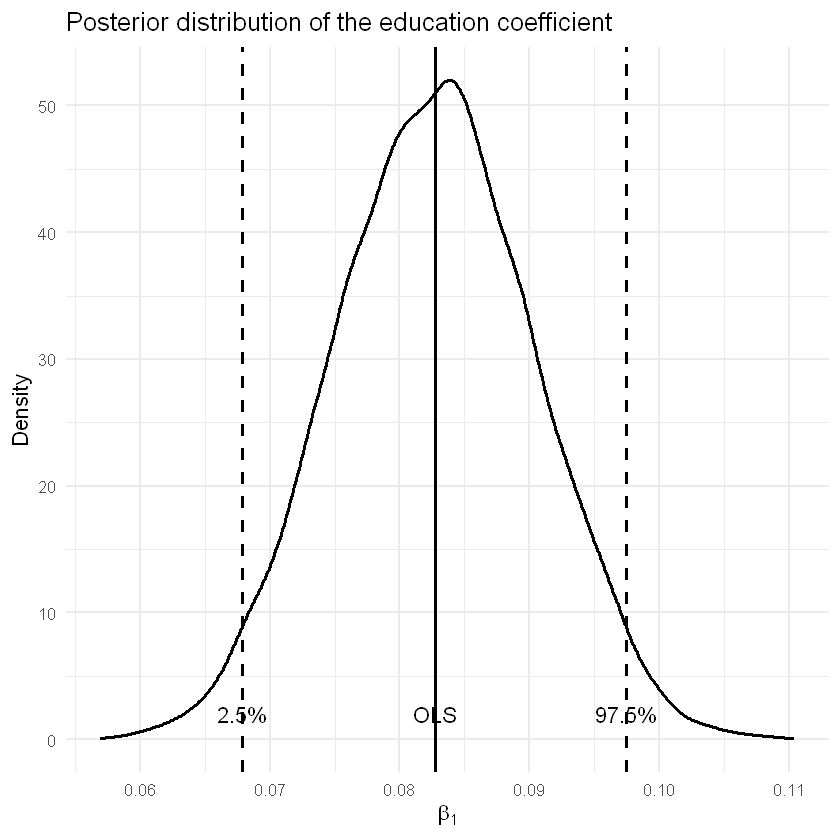

In [17]:
# Posterior summaries for the education coefficient

beta1_post <- bayes_fit[, "educ"]

posterior_mean <- mean(beta1_post)
posterior_sd <- sd(beta1_post)
credible_interval <- quantile(beta1_post, c(0.025, 0.975))
prob_positive <- mean(beta1_post > 0)

round(
  c(
    posterior_mean = posterior_mean,
    posterior_sd = posterior_sd,
    lower_95 = credible_interval[1],
    upper_95 = credible_interval[2],
    `P(beta1 > 0 | data)` = prob_positive
  ),
  4
)


post_data <- data.frame(beta1_post = beta1_post)

ggplot(post_data, aes(x = beta1_post)) +
  geom_density(linewidth = 1) +
  geom_vline(
    xintercept = credible_interval,
    linetype = "dashed",
    linewidth = 1
  ) +
  geom_vline(
    xintercept = coef(fit)["educ"],
    linewidth = 1
  ) +
  annotate("text", x = credible_interval[1], y = 0, label = "2.5%", vjust = -1) +
  annotate("text", x = credible_interval[2], y = 0, label = "97.5%", vjust = -1) +
  annotate("text", x = coef(fit)["educ"], y = 0, label = "OLS", vjust = -1) +
  labs(
    title = "Posterior distribution of the education coefficient",
    x = expression(beta[1]),
    y = "Density"
  ) +
  theme_minimal(base_size = 13)

In [ ]:
# Frequentist vs Bayesian summary for the education coefficient

ols_est <- coef(fit)["educ"]
ols_se  <- summary(fit)$coefficients["educ", "Std. Error"]
ols_ci  <- confint(fit, "educ", level = 0.95)

comparison <- rbind(
  Frequentist = c(
    estimate = unname(ols_est),
    se       = unname(ols_se),
    lower_95 = unname(ols_ci[1]),
    upper_95 = unname(ols_ci[2])
  ),
  Bayesian = c(
    estimate = unname(posterior_mean),
    se       = unname(posterior_sd),
    lower_95 = unname(credible_interval[1]),
    upper_95 = unname(credible_interval[2])
  )
)

round(comparison, 4)

The Bayesian result is interpreted directly from the posterior:

- the **posterior mean** is a point summary of $\beta_1$;
- the **posterior standard deviation** measures posterior uncertainty;
- the 95% **credible interval** contains 95% of the posterior probability for $\beta_1$;
- $P(\beta_1>0\mid y,X)$ is the posterior probability that the association between education and log wages is positive, conditional on the model and prior.

With a reasonably informative sample and weak priors, the Bayesian and frequentist numerical results will often be similar. Their **interpretations remain different**.


## Frequentist and Bayesian regression inference: side by side

| Question | Frequentist | Bayesian |
|:---|:---|:---|
| Parameter $\beta_1$ | fixed but unknown | uncertainty represented by a posterior distribution |
| Probability model | Gaussian regression | same Gaussian regression |
| Likelihood | $L(\beta_0,\beta_1,\sigma;y,X)$ | same likelihood |
| Additional ingredient | repeated-sampling principle | prior distribution |
| Point summary | OLS / MLE $\hat\beta_1$ | posterior mean/median/mode |
| Uncertainty measure | standard error | posterior standard deviation |
| 95% interval | confidence interval | credible interval |
| Direct probability such as $P(\beta_1>0\mid y)$ | not a frequentist parameter-probability statement | obtained directly from posterior draws |

**Same data. Same probability model. Same likelihood. Different treatment and interpretation of uncertainty.**

On `wage1` the two columns are numerically almost identical—both give a slope near **0.083** with a 95% interval close to **[0.068, 0.098]** (see the comparison table above). With 526 observations and weak priors the likelihood dominates, so the posterior sits essentially on top of the OLS estimate, and the posterior mean $\approx$ MLE. They would diverge if the sample were small or the prior strong—precisely the setting where Bayesian shrinkage becomes valuable, as in the VARs later in the course.